In [1]:
import nibabel as nib # Nibabel 라이브러리를 nib 라는 이름으로 가져옵니다.
import numpy as np   # 숫자 배열(Numpy array)을 다루기 위해 numpy도 가져옵니다.

In [8]:
# --- 1. NIfTI 파일 로드 ---
# .nii.gz 파일을 직접 로드합니다. 파일 경로를 실제 경로로 바꿔주세요.
# 예시: Structural 폴더의 T1w 영상
img_path = '100307_StructuralRecommended\\100307\T1w\T1w_acpc_dc_restore_brain.nii.gz'
# 예시: Task fMRI 폴더의 전처리된 4D 영상
# img_path = '100307/MNINonLinear/Results/tfMRI_WM_LR/tfMRI_WM_LR_hp0_clean_tclean.nii.gz'

In [9]:
try:
    img = nib.load(img_path)
    print(f"Successfully loaded: {img_path}")

    # --- 2. 이미지 데이터 접근 ---
    # get_fdata() 함수를 사용해 실제 이미지 데이터를 Numpy 배열 형태로 가져옵니다.
    # 데이터 타입은 보통 float 형태입니다.
    img_data = img.get_fdata()

    # 데이터의 형태(shape) 확인 (예: 3D 구조 영상, 4D fMRI 영상)
    print(f"Data shape: {img_data.shape}") # (x, y, z) 또는 (x, y, z, time)
    print(f"Data type: {img_data.dtype}")

    # (옵션) 데이터 값 일부 확인
    # print("Some data values:\n", img_data[100:102, 100:102, 100]) # 예시 슬라이싱

    # --- 3. 헤더 정보 접근 (옵션) ---
    # 이미지의 메타데이터(차원, 복셀 크기 등)가 담긴 헤더 정보 확인
    header = img.header
    # print("\nHeader Info:\n", header)
    voxel_size = header.get_zooms()
    print(f"Voxel size (x, y, z): {voxel_size[:3]}") # 복셀 크기 (mm)

    # --- 4. Affine 정보 접근 (옵션) ---
    # 이미지 공간과 실제 세계 공간 간의 좌표 변환 정보 (행렬)
    affine = img.affine
    print("\nAffine Matrix:\n", affine)

    # --- 5. 데이터 활용 ---
    # 이제 img_data (Numpy 배열)를 가지고 딥러닝 모델 입력 등으로 활용할 수 있습니다.
    # 예를 들어, CNN 모델에 입력하기 위해 전처리하거나 특정 영역 값을 추출하는 등...

except FileNotFoundError:
    print(f"Error: File not found at {img_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded: 100307_StructuralRecommended\100307\T1w\T1w_acpc_dc_restore_brain.nii.gz
Data shape: (260, 311, 260)
Data type: float64
Voxel size (x, y, z): (0.7, 0.7, 0.7)

Affine Matrix:
 [[  -0.69999999    0.            0.           90.        ]
 [   0.            0.69999999    0.         -126.        ]
 [   0.            0.            0.69999999  -72.        ]
 [   0.            0.            0.            1.        ]]


Data shape: (260, 311, 260)


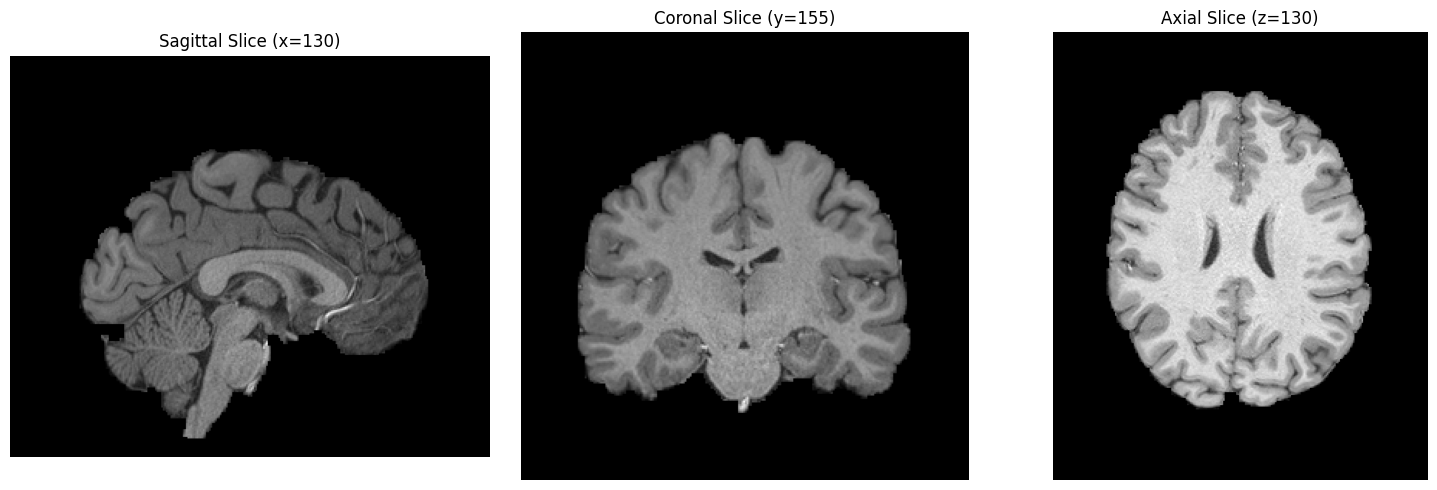

In [10]:
import matplotlib.pyplot as plt

try:
    img = nib.load(img_path)
    img_data = img.get_fdata()
    print(f"Data shape: {img_data.shape}")

    # --- 이미지 슬라이스 시각화 ---

    # 시각화할 슬라이스 인덱스 선택 (데이터 중간쯤)
    x_slice = img_data.shape[0] // 2 # Sagittal 중간 슬라이스
    y_slice = img_data.shape[1] // 2 # Coronal 중간 슬라이스
    z_slice = img_data.shape[2] // 2 # Axial 중간 슬라이스

    # 3개의 서브플롯 생성 (1행 3열)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Sagittal 슬라이스 표시 (x축 고정)
    #    Numpy 배열 인덱싱: [x, y, z] 순서
    #    imshow는 (y, z) 평면을 보여줘야 하므로, 데이터를 적절히 선택하고 회전(T)시킬 수 있음
    axes[0].imshow(np.rot90(img_data[x_slice, :, :]), cmap='gray')
    axes[0].set_title(f'Sagittal Slice (x={x_slice})')
    axes[0].axis('off') # 축 정보 끄기

    # 2. Coronal 슬라이스 표시 (y축 고정)
    axes[1].imshow(np.rot90(img_data[:, y_slice, :]), cmap='gray')
    axes[1].set_title(f'Coronal Slice (y={y_slice})')
    axes[1].axis('off')

    # 3. Axial 슬라이스 표시 (z축 고정)
    axes[2].imshow(np.rot90(img_data[:, :, z_slice]), cmap='gray')
    axes[2].set_title(f'Axial Slice (z={z_slice})')
    axes[2].axis('off')

    plt.tight_layout() # 서브플롯 간 간격 자동 조절
    plt.show() # 이미지 창 띄우기

except FileNotFoundError:
    print(f"Error: File not found at {img_path}")
except Exception as e:
    print(f"An error occurred: {e}")